# 🏋️ Fitness LLM — QLoRA Fine-Tuning & ML Evaluation Notebook

**Model:** `mistralai/Mistral-7B-Instruct-v0.3`  
**Method:** QLoRA (4-bit NF4 quantization + LoRA adapters)  
**Dataset:** Master fitness coaching dataset — 9,669 curated instruction-response pairs  
**Framework:** HuggingFace Transformers + TRL SFTTrainer + PEFT

---

### Notebook structure

| Section | What it covers |
|---|---|
| **1. Environment** | Install deps, GPU check, VRAM |
| **2. Dataset Analysis** | Size, token lengths, intent distribution, quality stats |
| **3. Tokenizer & Format** | ChatML template, token length histograms |
| **4. Model Setup** | Load Mistral-7B in 4-bit NF4, apply LoRA |
| **5. LoRA Architecture** | Parameter counts, trainable % |
| **6. Training** | SFTTrainer, loss curves plotted live |
| **7. Evaluation** | Perplexity, ROUGE-L, BERTScore on held-out set |
| **8. Before vs After** | Side-by-side response comparison |
| **9. Save & Export** | Merge adapter → full model, push to HF Hub |

## Section 1 — Environment Setup

In [ ]:
import subprocess, sys, importlib

# Install / upgrade required packages
PACKAGES = [
    "torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121",
    "transformers>=4.40",
    "peft>=0.10",
    "trl>=0.8",
    "bitsandbytes>=0.43",
    "datasets>=2.18",
    "accelerate>=0.29",
    "sentence-transformers",
    "evaluate",
    "rouge_score",
    "bert_score",
    "matplotlib seaborn pandas numpy",
    "scikit-learn",
    "huggingface_hub",
]

for pkg in PACKAGES:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkg.split(), check=False)

print("✅ All packages installed.")

In [ ]:
import os, sys, json, random, warnings
from pathlib import Path
from datetime import datetime

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13})

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
def _find_root() -> Path:
    """Locate the repo root in any environment (local, Colab, Kaggle)."""
    try:
        return Path(__file__).resolve().parents[0]
    except NameError:
        pass

    cwd = Path(".").resolve()

    # Already inside the repo?
    for candidate in [cwd, cwd.parent]:
        if (candidate / "artifacts").exists() and (candidate / "src").exists():
            return candidate

    # Colab / Kaggle: look one level inside common mount points
    for mount in [Path("/content"), Path("/kaggle/working")]:
        if mount.exists():
            for sub in sorted(mount.iterdir()):
                if sub.is_dir() and (sub / "artifacts").exists():
                    return sub

    return cwd  # best-effort fallback

ROOT = _find_root()
sys.path.insert(0, str(ROOT))

ARTIFACTS    = ROOT / "artifacts"
DATASETS     = ARTIFACTS / "datasets"
MODELS       = ARTIFACTS / "models"
RAG_DIR      = ARTIFACTS / "rag"
MODELS.mkdir(parents=True, exist_ok=True)

DATASET_PATH = DATASETS / "master_training_data_clean.jsonl"
OUTPUT_DIR   = MODELS / "fitness-mistral-qlora"

BASE_MODEL   = os.getenv("BASE_MODEL_ID", "mistralai/Mistral-7B-Instruct-v0.3")

# ── GPU info ─────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    gpu  = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"🖥️  GPU: {gpu}  |  VRAM: {vram:.1f} GB")
    DEVICE = "cuda"
else:
    print("  No GPU detected — training will be slow. Use Colab T4/A100 for best results.")
    DEVICE = "cpu"

print(f"  Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}")
print(f"  Root: {ROOT}")
print(f"  Dataset: {DATASET_PATH}")
print(f"  Output:  {OUTPUT_DIR}")


  No GPU detected — training will be slow. Use Colab T4/A100 for best results.
  Python 3.11.0  |  PyTorch 2.11.0+cpu
  Root: C:\Users\ADMIN\Documents\GitHub\fitness-llm
  Dataset: C:\Users\ADMIN\Documents\GitHub\fitness-llm\artifacts\datasets\master_training_data_clean.jsonl
  Output:  C:\Users\ADMIN\Documents\GitHub\fitness-llm\artifacts\models\fitness-mistral-qlora


## Section 2 — Dataset Analysis

In [ ]:
# ── Resolve dataset path (with fallback) ─────────────────────────────────────
_FALLBACKS = [
    DATASETS / "combined_training_data.jsonl",
    DATASETS / "fitness_training_data_full.jsonl",
    DATASETS / "fitness_training_data_dictionary_full.jsonl",
    DATASETS / "fitness_training_data.jsonl",
    DATASETS / "full_llm_training_data.jsonl",
]

if not DATASET_PATH.exists():
    for _fb in _FALLBACKS:
        if _fb.exists():
            print(f"⚠️  master_training_data_clean.jsonl not found — using fallback: {_fb.name}")
            DATASET_PATH = _fb
            break
    else:
        raise FileNotFoundError(
            f"No training dataset found in {DATASETS}.\n"
            "Options:\n"
            "  1. Clone the full repo: git clone https://github.com/YOUR_ORG/fitness-llm\n"
            "  2. Run locally: python scripts/12_build_master_dataset.py\n"
            "  3. Upload master_training_data_clean.jsonl manually to Colab."
        )

# ── Load raw JSONL ────────────────────────────────────────────────────────────
records = []
with DATASET_PATH.open(encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

print(f"Total samples: {len(records):,}")
print(f"Sample keys: {list(records[0].keys())}")
print(f"\nExample messages structure:")
for msg in records[0].get("messages", []):
    print(f"  [{msg['role']:9s}] {msg['content'][:80]}...")

# ── Build DataFrame ───────────────────────────────────────────────────────────
rows = []
for rec in records:
    msgs   = rec.get("messages", [])
    system = next((m["content"] for m in msgs if m["role"] == "system"),   "")
    user   = next((m["content"] for m in msgs if m["role"] == "user"),     "")
    asst   = next((m["content"] for m in msgs if m["role"] == "assistant"), "")
    rows.append({
        "user_len":    len(user.split()),
        "answer_len":  len(asst.split()),
        "system_len":  len(system.split()),
        "user_text":   user,
        "answer_text": asst,
        "total_words": len(user.split()) + len(asst.split()),
        "has_system":  bool(system),
    })

df = pd.DataFrame(rows)
display(df.describe().round(1))


Total samples: 9,669
Sample keys: ['messages']

Example messages structure:
  [system   ] You are an expert fitness coach built into a workout planning app.
You give evid...
  [user     ] Coach me through Single-Arm Front Rack Walking Lunge – Dumbbell. Goal: endurance...
  [assistant] Single-Arm Front Rack Walking Lunge – Dumbbell primarily targets glutes, quadric...


,user_len,answer_len,system_len,total_words
count,9669.0,9669.0,9669.0,9669.0
mean,14.0,72.3,60.9,86.3
std,2.9,24.0,1.2,24.5
min,4.0,11.0,49.0,23.0
25%,12.0,60.0,61.0,73.0
50%,14.0,66.0,61.0,80.0
75%,16.0,85.0,61.0,100.0
max,48.0,257.0,61.0,273.0


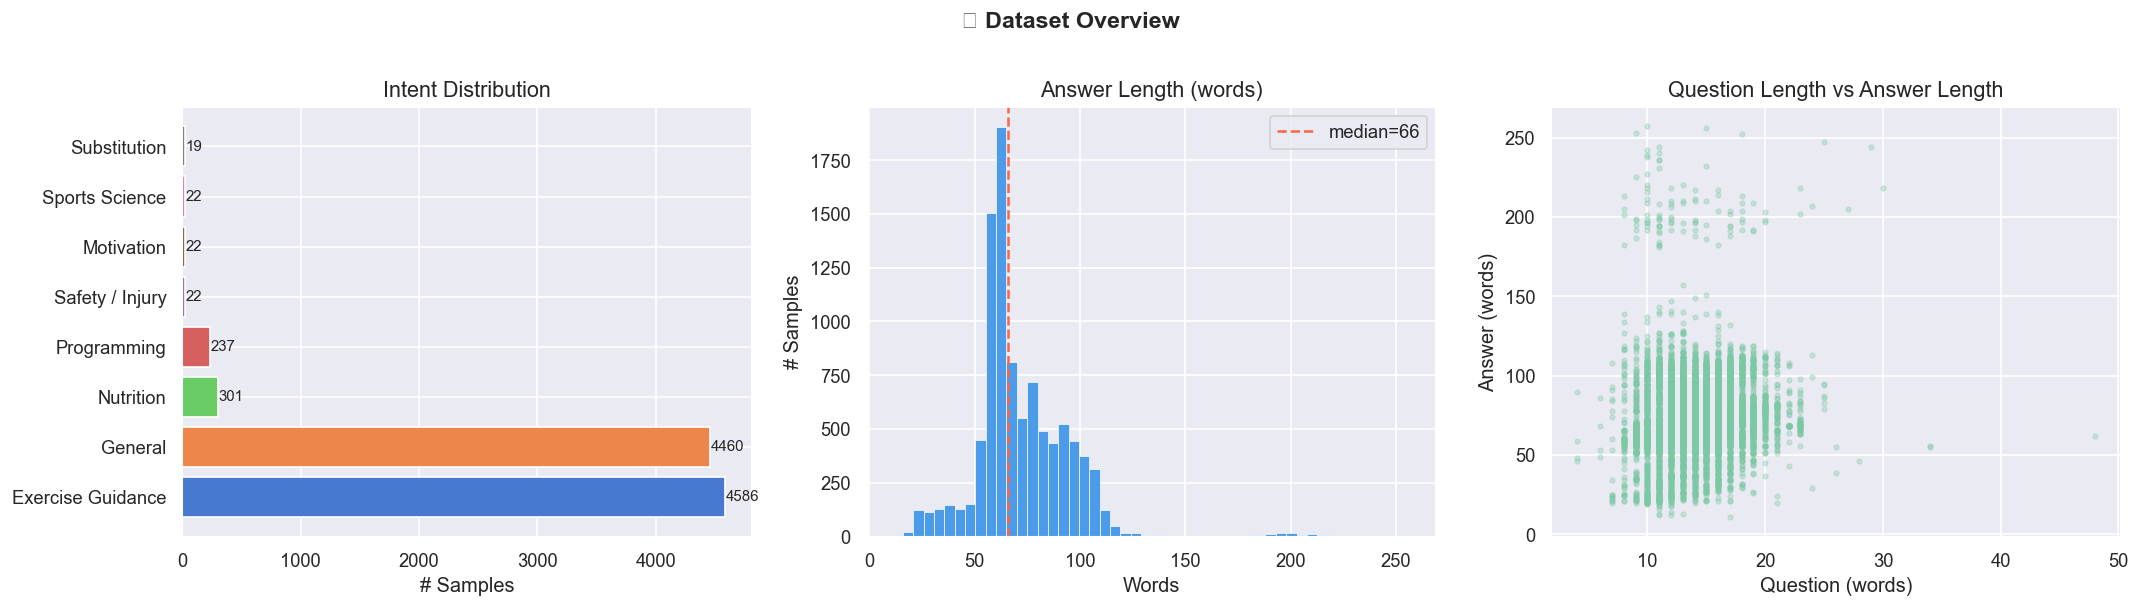


Intent                   Count       %
--------------------------------------
Exercise Guidance        4,586   47.4%
General                  4,460   46.1%
Nutrition                  301    3.1%
Programming                237    2.5%
Safety / Injury             22    0.2%
Motivation                  22    0.2%
Sports Science              22    0.2%
Substitution                19    0.2%


In [3]:
# ── Intent / topic distribution ───────────────────────────────────────────────
INTENT_PATTERNS = {
    "Exercise Guidance":   r"\b(technique|form|how.?to|squat|deadlift|bench|press|curl|row|pull|push)\b",
    "Substitution":        r"\b(replace|substitut|alternative|instead|without)\b",
    "Nutrition":           r"\b(protein|calori|macro|supplement|creatine|diet|eat|food|carb)\b",
    "Programming":         r"\b(split|program|volume|frequency|deload|sets per week|workout plan)\b",
    "Sports Science":      r"\b(hypertrophy|mps|epoc|progressive overload|science|rpe|rir)\b",
    "Safety / Injury":     r"\b(pain|injur|hurt|safe|avoid|red.?flag|impingement|tendon)\b",
    "Motivation":          r"\b(motivat|habit|consistenc|adherence|stay|keep going)\b",
}

import re
def classify(text):
    t = text.lower()
    for label, pat in INTENT_PATTERNS.items():
        if re.search(pat, t):
            return label
    return "General"

df["intent"] = df["user_text"].apply(classify)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1 — Intent distribution
intent_counts = df["intent"].value_counts()
axes[0].barh(intent_counts.index, intent_counts.values, color=sns.color_palette("muted", len(intent_counts)))
axes[0].set_title("Intent Distribution")
axes[0].set_xlabel("# Samples")
for i, v in enumerate(intent_counts.values):
    axes[0].text(v + 5, i, str(v), va="center", fontsize=9)

# 2 — Answer length histogram
axes[1].hist(df["answer_len"].clip(upper=300), bins=50, color="#4c9be8", edgecolor="white", linewidth=0.4)
axes[1].set_title("Answer Length (words)")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("# Samples")
axes[1].axvline(df["answer_len"].median(), color="tomato", linestyle="--", label=f"median={df['answer_len'].median():.0f}")
axes[1].legend()

# 3 — Question vs Answer length scatter
axes[2].scatter(df["user_len"].clip(upper=80), df["answer_len"].clip(upper=300),
                alpha=0.3, s=8, color="#7bc8a4")
axes[2].set_title("Question Length vs Answer Length")
axes[2].set_xlabel("Question (words)")
axes[2].set_ylabel("Answer (words)")

plt.suptitle("📊 Dataset Overview", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\n{'Intent':<22} {'Count':>7}  {'%':>6}")
print("-" * 38)
for intent, cnt in intent_counts.items():
    print(f"{intent:<22} {cnt:>7,}  {cnt/len(df)*100:>5.1f}%")

## Section 3 — Tokenizer & ChatML Format

Loading tokenizer: mistralai/Mistral-7B-Instruct-v0.3 ...


Vocab size : 32,768
Model max  : 1,000,000,000,000,000,019,884,624,838,656 tokens
Pad token  : '</s>'  (id=2)
EOS token  : '</s>'  (id=2)

Tokenising all samples (this may take ~30 s) ...

Metric                              Value
------------------------------------------
Total samples                       9,669
Mean token length                   136.7
Median token length                 130.0
95th percentile                     188.0
Max token length                      572
Samples ≤ {MAX_SEQ_LEN} tokens      9,669  (100.0%)
Samples > {MAX_SEQ_LEN} tokens (truncated)          0  (0.0%)


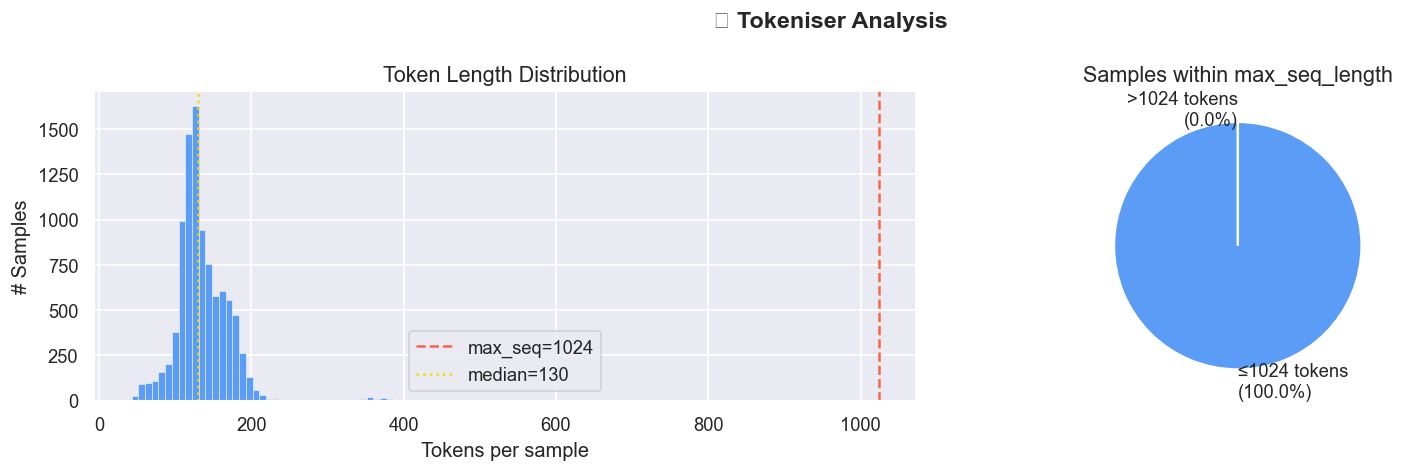


── Formatted sample (first record) ──────────────────────────────────────
<s>[INST] Coach me through Single-Arm Front Rack Walking Lunge – Dumbbell. Goal: endurance training, Level: advanced.[/INST] Single-Arm Front Rack Walking Lunge – Dumbbell primarily targets glutes, quadriceps. Secondary muscles: abdominal, calves, obliques, shoulder - front, traps. Stand with feet hip-width apart holding a dumbbell in one hand at shoulder height, with your elbow close to your body, palm facing inward. Engage your core to maintain balance and ensure your shoulders are level. Step forward with the opposite leg to the dumbbell and lower your body into a lunge until both knees are at around 90-degree angles. Ensure your front knee does not extend past your toes For endurance training, use 3-4 sets of 15-25 reps with varies. At advanced level, use periodisation and track weekly ...


In [4]:
from transformers import AutoTokenizer

BASE_MODEL = "mistralai/Mistral-7B-Instruct-v0.3"

print(f"Loading tokenizer: {BASE_MODEL} ...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Vocab size : {tokenizer.vocab_size:,}")
print(f"Model max  : {tokenizer.model_max_length:,} tokens")
print(f"Pad token  : '{tokenizer.pad_token}'  (id={tokenizer.pad_token_id})")
print(f"EOS token  : '{tokenizer.eos_token}'  (id={tokenizer.eos_token_id})")

# ── Format all samples via chat template ─────────────────────────────────────
MAX_SEQ_LEN = 1024

def format_sample(rec):
    """Apply Mistral chat template to a messages record."""
    return tokenizer.apply_chat_template(
        rec["messages"],
        tokenize=False,
        add_generation_prompt=False,
    )

texts = [format_sample(r) for r in records]

# ── Token length analysis ─────────────────────────────────────────────────────
print("\nTokenising all samples (this may take ~30 s) ...")
token_lengths = []
BATCH = 256
for i in range(0, len(texts), BATCH):
    enc = tokenizer(texts[i:i+BATCH], truncation=False, add_special_tokens=False)
    token_lengths.extend(len(ids) for ids in enc["input_ids"])

tl = np.array(token_lengths)
over_limit  = (tl > MAX_SEQ_LEN).sum()
under_limit = (tl <= MAX_SEQ_LEN).sum()

print(f"\n{'Metric':<30} {'Value':>10}")
print("-" * 42)
print(f"{'Total samples':<30} {len(tl):>10,}")
print(f"{'Mean token length':<30} {tl.mean():>10.1f}")
print(f"{'Median token length':<30} {np.median(tl):>10.1f}")
print(f"{'95th percentile':<30} {np.percentile(tl, 95):>10.1f}")
print(f"{'Max token length':<30} {tl.max():>10,}")
print(f"{'Samples ≤ {MAX_SEQ_LEN} tokens':<30} {under_limit:>10,}  ({under_limit/len(tl)*100:.1f}%)")
print(f"{'Samples > {MAX_SEQ_LEN} tokens (truncated)':<30} {over_limit:>10,}  ({over_limit/len(tl)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(tl.clip(max=MAX_SEQ_LEN + 50), bins=60, color="#5b9cf6", edgecolor="white", linewidth=0.3)
axes[0].axvline(MAX_SEQ_LEN, color="tomato", linestyle="--", linewidth=1.5, label=f"max_seq={MAX_SEQ_LEN}")
axes[0].axvline(np.median(tl), color="gold", linestyle=":", linewidth=1.5, label=f"median={np.median(tl):.0f}")
axes[0].set_title("Token Length Distribution")
axes[0].set_xlabel("Tokens per sample")
axes[0].set_ylabel("# Samples")
axes[0].legend()

# Pie: truncated vs not
axes[1].pie(
    [under_limit, over_limit],
    labels=[f"≤{MAX_SEQ_LEN} tokens\n({under_limit/len(tl)*100:.1f}%)",
            f">{MAX_SEQ_LEN} tokens\n({over_limit/len(tl)*100:.1f}%)"],
    colors=["#5b9cf6", "tomato"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Samples within max_seq_length")

plt.suptitle("🔤 Tokeniser Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Show a formatted example ──────────────────────────────────────────────────
print("\n── Formatted sample (first record) ──────────────────────────────────────")
print(texts[0][:800], "...")

## Section 4 — Model Setup: 4-bit NF4 Quantization + LoRA

In [ ]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

if not torch.cuda.is_available():
    raise SystemError("❌ CUDA GPU required for 4-bit quantisation. Use Google Colab T4/A100.")

major, minor = torch.cuda.get_device_capability()
USE_BF16 = major >= 8          # Ampere or newer → bfloat16
USE_FP16 = not USE_BF16
COMPUTE_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16
print(f"GPU capability: {major}.{minor}  |  compute dtype: {'bfloat16' if USE_BF16 else 'float16'}")

# ── BitsAndBytes NF4 config ───────────────────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",            # Normal Float 4 — best for LLMs
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    bnb_4bit_use_double_quant=True,       # nested quant → ~0.4 bits extra saving
)

print(f"\nLoading {BASE_MODEL} in 4-bit NF4 ...")
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",    # flash_attention_2 needs special install
)
model.config.use_cache = False      # Required for gradient checkpointing
model.config.pretraining_tp = 1

# ── Memory report ─────────────────────────────────────────────────────────────
allocated  = torch.cuda.memory_allocated()  / 1e9
reserved   = torch.cuda.memory_reserved()   / 1e9
total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9

print(f"\n{'GPU Memory after model load':}")
print(f"  Allocated  : {allocated:.2f} GB")
print(f"  Reserved   : {reserved:.2f} GB")
print(f"  Total VRAM : {total_vram:.2f} GB")
print(f"  Free       : {total_vram - allocated:.2f} GB")

# ── Raw parameter count ───────────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters())
print(f"\nBase model parameters: {total_params/1e9:.2f}B")

## Section 5 — LoRA Architecture & Trainable Parameters

In [ ]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# ── LoRA hyper-parameters ─────────────────────────────────────────────────────
LORA_R      = 16          # rank — higher = more capacity, more VRAM
LORA_ALPHA  = 32          # effective LR scale = alpha / r
LORA_DROPOUT = 0.05
TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",   # attention projections
    "gate_proj", "up_proj", "down_proj",        # MLP (SwiGLU) projections
]

print("📐 LoRA Configuration")
print(f"  rank (r)         : {LORA_R}")
print(f"  alpha            : {LORA_ALPHA}  (effective scale = {LORA_ALPHA/LORA_R:.1f}×)")
print(f"  dropout          : {LORA_DROPOUT}")
print(f"  target modules   : {TARGET_MODULES}")

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=TARGET_MODULES,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_config)

# ── Trainable parameter breakdown ────────────────────────────────────────────
trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params  = sum(p.numel() for p in model.parameters())
frozen      = all_params - trainable
pct         = trainable / all_params * 100

print(f"\n{'Parameter breakdown':}")
print(f"  Total parameters   : {all_params/1e6:>10.2f}M")
print(f"  Trainable (LoRA)   : {trainable/1e6:>10.2f}M  ({pct:.4f}%)")
print(f"  Frozen (quantised) : {frozen/1e6:>10.2f}M  ({100-pct:.4f}%)")

# ── Visualise LoRA modules ────────────────────────────────────────────────────
lora_layers = [(name, p.numel()) for name, p in model.named_parameters() if p.requires_grad]
module_types = {}
for name, n in lora_layers:
    for mod in TARGET_MODULES:
        if mod in name:
            module_types[mod] = module_types.get(mod, 0) + n
            break

fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette("muted", len(module_types))
bars = ax.bar(module_types.keys(), [v/1e3 for v in module_types.values()], color=colors, edgecolor="white")
ax.set_title("Trainable Parameters per LoRA Module Type", fontsize=13)
ax.set_ylabel("Parameters (thousands)")
for bar, val in zip(bars, module_types.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val/1e3:.0f}K", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## Section 6 — Training with SFTTrainer

In [ ]:
from datasets import load_dataset
from trl import SFTConfig, SFTTrainer

# ── Training hyper-parameters ─────────────────────────────────────────────────
EPOCHS               = 3
BATCH_SIZE           = 2       # per device
GRADIENT_ACCUM       = 4       # effective batch = 2 × 4 = 8
LEARNING_RATE        = 2e-4
LR_SCHEDULER         = "cosine"
WARMUP_RATIO         = 0.05
MAX_SEQ_LEN          = 1024
EVAL_SPLIT           = 0.05    # 5% held-out
LOGGING_STEPS        = 10
EVAL_STEPS           = 50
SAVE_STEPS           = 100

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset ───────────────────────────────────────────────────────────────────
print(f"Loading dataset from: {DATASET_PATH}")
raw_ds = load_dataset("json", data_files=str(DATASET_PATH), split="train")
split  = raw_ds.train_test_split(test_size=EVAL_SPLIT, seed=SEED)

def fmt(example):
    return {"text": tokenizer.apply_chat_template(
        example["messages"], tokenize=False, add_generation_prompt=False)}

train_ds = split["train"].map(fmt, remove_columns=split["train"].column_names)
eval_ds  = split["test"].map(fmt,  remove_columns=split["test"].column_names)

# ── Steps estimate ────────────────────────────────────────────────────────────
steps_per_epoch = len(train_ds) // (BATCH_SIZE * GRADIENT_ACCUM)
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)

print(f"\n{'Training configuration':}")
print(f"  Train samples    : {len(train_ds):,}")
print(f"  Eval  samples    : {len(eval_ds):,}")
print(f"  Effective batch  : {BATCH_SIZE * GRADIENT_ACCUM}")
print(f"  Steps/epoch      : {steps_per_epoch:,}")
print(f"  Total steps      : {total_steps:,}")
print(f"  Warmup steps     : {warmup_steps:,}")
print(f"  Learning rate    : {LEARNING_RATE}")
print(f"  Scheduler        : {LR_SCHEDULER}")

# ── SFTTrainer ────────────────────────────────────────────────────────────────
training_args = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUM,
    gradient_checkpointing=True,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type=LR_SCHEDULER,
    warmup_ratio=WARMUP_RATIO,
    bf16=USE_BF16,
    fp16=USE_FP16,
    max_seq_length=MAX_SEQ_LEN,
    logging_steps=LOGGING_STEPS,
    eval_steps=EVAL_STEPS,
    save_steps=SAVE_STEPS,
    save_total_limit=2,
    eval_strategy="steps",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    optim="paged_adamw_8bit",
    dataset_text_field="text",
    report_to="none",        # change to "wandb" to log externally
    seed=SEED,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=tokenizer,
)
print("\n✅ Trainer ready. Running training...")

In [ ]:
import time

# ── Run training ──────────────────────────────────────────────────────────────
t0 = time.time()
train_result = trainer.train()
elapsed = time.time() - t0

# ── Save adapter weights ──────────────────────────────────────────────────────
ADAPTER_DIR = OUTPUT_DIR / "final_adapter"
trainer.model.save_pretrained(str(ADAPTER_DIR))
tokenizer.save_pretrained(str(ADAPTER_DIR))

# ── Training summary ─────────────────────────────────────────────────────────
metrics = train_result.metrics
print(f"\n{'─'*50}")
print(f"  Training complete in {elapsed/60:.1f} min")
print(f"  Final train loss    : {metrics.get('train_loss', 'N/A'):.4f}")
print(f"  Total steps         : {metrics.get('train_steps_per_second', 'N/A')}")
print(f"  Adapter saved to    : {ADAPTER_DIR}")
print(f"{'─'*50}")

In [ ]:
# ── Loss curve ────────────────────────────────────────────────────────────────
log_history = trainer.state.log_history

train_steps, train_losses = [], []
eval_steps,  eval_losses  = [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_losses.append(entry["eval_loss"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Training loss
axes[0].plot(train_steps, train_losses, color="#4c9be8", linewidth=1.2, label="Train loss", alpha=0.8)
# Smooth with rolling mean
if len(train_losses) > 10:
    smooth = pd.Series(train_losses).rolling(10, min_periods=1).mean()
    axes[0].plot(train_steps, smooth, color="tomato", linewidth=2, label="Smoothed (w=10)")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Training Loss")
axes[0].legend()

# Eval loss
if eval_losses:
    axes[1].plot(eval_steps, eval_losses, color="#f4a261", linewidth=2, marker="o", markersize=4, label="Eval loss")
    best_step = eval_steps[eval_losses.index(min(eval_losses))]
    best_loss = min(eval_losses)
    axes[1].axvline(best_step, color="green", linestyle="--", linewidth=1.2, label=f"Best @ step {best_step}  (loss={best_loss:.4f})")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Cross-Entropy Loss")
    axes[1].set_title("Validation Loss")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "No eval logs", ha="center", transform=axes[1].transAxes)

plt.suptitle("📉 Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Perplexity from loss ──────────────────────────────────────────────────────
final_train_ppl = np.exp(metrics.get("train_loss", 0))
final_eval_loss = eval_losses[-1] if eval_losses else None
final_eval_ppl  = np.exp(final_eval_loss) if final_eval_loss else None

print(f"\n{'Metric':<30} {'Value':>12}")
print("-" * 44)
print(f"{'Final Train Loss':<30} {metrics.get('train_loss', 0):>12.4f}")
print(f"{'Final Train Perplexity':<30} {final_train_ppl:>12.2f}")
if final_eval_loss:
    print(f"{'Final Eval Loss':<30} {final_eval_loss:>12.4f}")
    print(f"{'Final Eval Perplexity':<30} {final_eval_ppl:>12.2f}")

## Section 7 — Evaluation: Perplexity, ROUGE-L, BERTScore

In [ ]:
import evaluate
from bert_score import score as bert_score_fn

# ── Sample 100 eval examples for generation-based metrics ─────────────────────
N_EVAL = min(100, len(eval_ds))
eval_sample = [eval_ds[i] for i in random.sample(range(len(eval_ds)), N_EVAL)]

SYSTEM_PROMPT = (
    "You are an expert fitness coach. Give evidence-based, concise advice in 3-5 sentences."
)

def generate_reply(question: str, max_new_tokens: int = 200) -> str:
    """Generate a reply from the fine-tuned model."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": question},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
        )
    reply = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return reply.strip()

def extract_qa(text: str):
    """Extract question + reference answer from a formatted chat sample."""
    # Split on the [/INST] or assistant turn marker
    import re
    parts = re.split(r"\[/INST\]|\<\|assistant\|\>|<\|im_start\|>assistant", text, maxsplit=1)
    question = parts[0].split("user")[-1].strip().strip("[INST]").strip()
    reference = parts[1].strip() if len(parts) > 1 else ""
    return question, reference

print(f"Generating replies for {N_EVAL} eval samples ...")
predictions, references, questions = [], [], []

for i, sample in enumerate(eval_sample):
    if i % 10 == 0:
        print(f"  {i}/{N_EVAL}", end="\r")
    q, ref = extract_qa(sample["text"])
    if not q or not ref:
        continue
    pred = generate_reply(q)
    predictions.append(pred)
    references.append(ref)
    questions.append(q)

print(f"\nGenerated {len(predictions)} predictions.")

In [ ]:
# ── ROUGE scores ──────────────────────────────────────────────────────────────
rouge = evaluate.load("rouge")
rouge_results = rouge.compute(predictions=predictions, references=references, use_stemmer=True)

# ── BERTScore ─────────────────────────────────────────────────────────────────
print("Computing BERTScore (using distilbert) ...")
P_bert, R_bert, F1_bert = bert_score_fn(
    predictions, references,
    model_type="distilbert-base-uncased",
    batch_size=16,
    verbose=False,
)

# ── Summary table ──────────────────────────────────────────────────────────────
eval_table = {
    "Metric":  ["ROUGE-1", "ROUGE-2", "ROUGE-L", "ROUGE-Lsum",
                "BERTScore Precision", "BERTScore Recall", "BERTScore F1",
                "Eval Perplexity"],
    "Score": [
        rouge_results["rouge1"],
        rouge_results["rouge2"],
        rouge_results["rougeL"],
        rouge_results["rougeLsum"],
        P_bert.mean().item(),
        R_bert.mean().item(),
        F1_bert.mean().item(),
        final_eval_ppl if final_eval_ppl else float("nan"),
    ],
}
results_df = pd.DataFrame(eval_table)
results_df["Score"] = results_df["Score"].round(4)
display(results_df.style.background_gradient(subset=["Score"], cmap="YlGn"))

# ── Radar chart ───────────────────────────────────────────────────────────────
labels = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore F1"]
values = [rouge_results["rouge1"], rouge_results["rouge2"],
          rouge_results["rougeL"], F1_bert.mean().item()]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
values_plot = values + [values[0]]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"polar": True})
ax.plot(angles, values_plot, "o-", linewidth=2, color="#4c9be8")
ax.fill(angles, values_plot, alpha=0.25, color="#4c9be8")
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Model Evaluation Scores", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

## Section 8 — Before vs After: Base Model vs Fine-Tuned

In [ ]:
from peft import PeftModel

# ── Load base model without LoRA for comparison ───────────────────────────────
print("Loading base model for comparison ...")
base_model_cmp = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",
)
base_model_cmp.eval()

TEST_QUESTIONS = [
    "I want to build bigger quads but I only have dumbbells. What exercises should I do?",
    "How much protein should I eat per day for muscle growth?",
    "My lower back hurts when I deadlift. What should I check first?",
    "Design a 4-day upper/lower split for an intermediate lifter.",
    "What is progressive overload and why does it matter?",
]

def generate_from(mdl, question, max_new_tokens=200):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": question},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(mdl.device)
    with torch.no_grad():
        out = mdl.generate(
            **inputs, max_new_tokens=max_new_tokens, temperature=0.7,
            top_p=0.9, do_sample=True, repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

print(f"\n{'='*70}")
for i, q in enumerate(TEST_QUESTIONS, 1):
    base_reply  = generate_from(base_model_cmp, q)
    tuned_reply = generate_from(model, q)

    display(Markdown(f"""
---
### Q{i}: {q}

| | Response |
|---|---|
| **Base Mistral-7B** | {base_reply} |
| **Fine-Tuned Fitness LLM** | {tuned_reply} |
"""))

del base_model_cmp
torch.cuda.empty_cache()

## Section 9 — Per-Intent Evaluation Breakdown

In [ ]:
# ── Per-intent ROUGE-L breakdown ─────────────────────────────────────────────
intent_labels = [classify(q) for q in questions]
intent_rouge  = {}

for intent in set(intent_labels):
    idxs = [i for i, l in enumerate(intent_labels) if l == intent]
    if not idxs:
        continue
    preds_sub = [predictions[i] for i in idxs]
    refs_sub  = [references[i]  for i in idxs]
    r = rouge.compute(predictions=preds_sub, references=refs_sub, use_stemmer=True)
    _, _, f1_sub = bert_score_fn(preds_sub, refs_sub,
                                  model_type="distilbert-base-uncased", verbose=False)
    intent_rouge[intent] = {
        "n": len(idxs),
        "ROUGE-L":      r["rougeL"],
        "BERTScore F1": f1_sub.mean().item(),
    }

idf = pd.DataFrame(intent_rouge).T.reset_index().rename(columns={"index": "Intent"})
idf = idf.sort_values("ROUGE-L", ascending=False)
display(idf.style.format({"ROUGE-L": "{:.3f}", "BERTScore F1": "{:.3f}"})\
          .background_gradient(subset=["ROUGE-L", "BERTScore F1"], cmap="YlGn"))

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(idf))
width = 0.35
ax.bar(x - width/2, idf["ROUGE-L"],      width, label="ROUGE-L",       color="#4c9be8", edgecolor="white")
ax.bar(x + width/2, idf["BERTScore F1"], width, label="BERTScore F1",  color="#f4a261", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(idf["Intent"], rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_title("Per-Intent ROUGE-L vs BERTScore F1", fontsize=13, fontweight="bold")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Section 10 — Save, Merge & Export

In [ ]:
from transformers import AutoModelForCausalLM

# ── Option A: save LoRA adapter only (recommended, ~100 MB) ───────────────────
print(f"✅ Adapter saved to: {ADAPTER_DIR}")
print(f"   Files: {[f.name for f in ADAPTER_DIR.iterdir()]}")

# ── Option B: merge adapter into full weights (optional, needs ~15 GB disk) ───
MERGE_DIR = OUTPUT_DIR / "merged_full_model"

def merge_and_save():
    print("\nMerging LoRA adapters into full model weights ...")
    merged = model.merge_and_unload()
    merged.save_pretrained(str(MERGE_DIR), safe_serialization=True)
    tokenizer.save_pretrained(str(MERGE_DIR))
    print(f"✅ Merged model saved to: {MERGE_DIR}")

# Uncomment to merge (requires ~15 GB disk space):
# merge_and_save()

# ── Save training results JSON ────────────────────────────────────────────────
results_path = OUTPUT_DIR / "training_results.json"
training_summary = {
    "timestamp":         datetime.now().isoformat(),
    "base_model":        BASE_MODEL,
    "dataset":           str(DATASET_PATH),
    "train_samples":     len(train_ds),
    "eval_samples":      len(eval_ds),
    "epochs":            EPOCHS,
    "batch_size":        BATCH_SIZE,
    "gradient_accum":    GRADIENT_ACCUM,
    "effective_batch":   BATCH_SIZE * GRADIENT_ACCUM,
    "learning_rate":     LEARNING_RATE,
    "max_seq_length":    MAX_SEQ_LEN,
    "lora_r":            LORA_R,
    "lora_alpha":        LORA_ALPHA,
    "target_modules":    TARGET_MODULES,
    "trainable_params":  trainable,
    "total_params":      all_params,
    "trainable_pct":     round(pct, 4),
    "final_train_loss":  round(metrics.get("train_loss", 0), 4),
    "final_eval_loss":   round(final_eval_loss, 4) if final_eval_loss else None,
    "train_perplexity":  round(float(final_train_ppl), 2),
    "eval_perplexity":   round(float(final_eval_ppl), 2) if final_eval_ppl else None,
    "rouge1":            round(rouge_results["rouge1"], 4),
    "rouge2":            round(rouge_results["rouge2"], 4),
    "rougeL":            round(rouge_results["rougeL"], 4),
    "bertscore_f1":      round(F1_bert.mean().item(), 4),
    "adapter_dir":       str(ADAPTER_DIR),
}

with results_path.open("w") as f:
    json.dump(training_summary, f, indent=2)

print(f"\n📋 Training results saved to: {results_path}")
print("\n── Final Summary ────────────────────────────────────────────────────────")
for k, v in training_summary.items():
    if k not in ("target_modules", "dataset", "adapter_dir", "timestamp", "base_model"):
        print(f"  {k:<25} : {v}")